In [3]:
from funasr import AutoModel

model = AutoModel(model="iic/emotion2vec_plus_large",
hub="hf")

funasr version: 1.3.1.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.3.1


Fetching 9 files: 100%|██████████| 9/9 [00:06<00:00,  1.49it/s]


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion

In [5]:
import librosa
sr = 16000
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"

import os
os.path.exists(audio_path)

True

In [23]:

y,_ = librosa.load(audio_path, sr=sr)

In [24]:
y.dtype

dtype('float32')

In [35]:
import numpy as np

window_samples = 3 * sr   # 32000
hop_samples = 1 * sr       # 16000
batch_size = 25

# Zero-copy strided view — shape: (frame_length, n_frames)
frames = librosa.util.frame(y, frame_length=window_samples, hop_length=hop_samples)
frames = frames.T  # (n_frames, frame_length) — each row is a 2s slice

# # Iterate in batches
# for i in range(0, len(frames), batch_size):
#     #batch = np.ascontiguousarray(frames[i:i + batch_size])  # (<=10, 32000)
#     batch = [np.ascontiguousarray(frames[j]) for j in range(i, min(i + batch_size, len(frames)))]
#     # feed batch to model
#     res = model.generate(
#     input=batch,
#     fs=16000,
#     granularity="utterance",
#     extract_embedding=False,
# )

In [36]:
all_scores = []
labels = None

for i in range(0, len(frames), batch_size):
    batch = [np.ascontiguousarray(frames[j]) for j in range(i, min(i + batch_size, len(frames)))]
    res = model.generate(input=batch, fs=16000, granularity="utterance", extract_embedding=False)
    
    if labels is None:
        labels = [l.split("/")[-1] if "/" in l else l for l in res[0]["labels"]]
    
    all_scores.extend(r["scores"] for r in res)

scores = np.array(all_scores, dtype=np.float32)  # (n_windows, 9)

rtf_avg: 0.004: 100%|██████████| 15/15 [00:00<00:00, 49.70it/s]                                                                                      


In [37]:
scores.shape

(3540, 9)

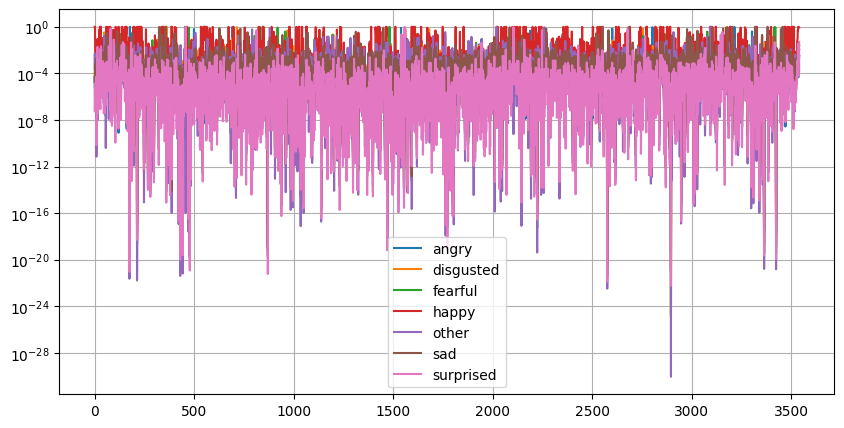

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
for idx in range(scores.shape[1]):
    if 'neutral' in labels[idx] or 'unk' in labels[idx]:
        continue
    ax.plot(scores[:, idx], label=labels[idx])
# lines = ax.plot(scores) # Plots all columns at once
ax.legend() # Map the list of labels to the created lines
ax.grid(True)
ax.set_yscale("log")
plt.show()


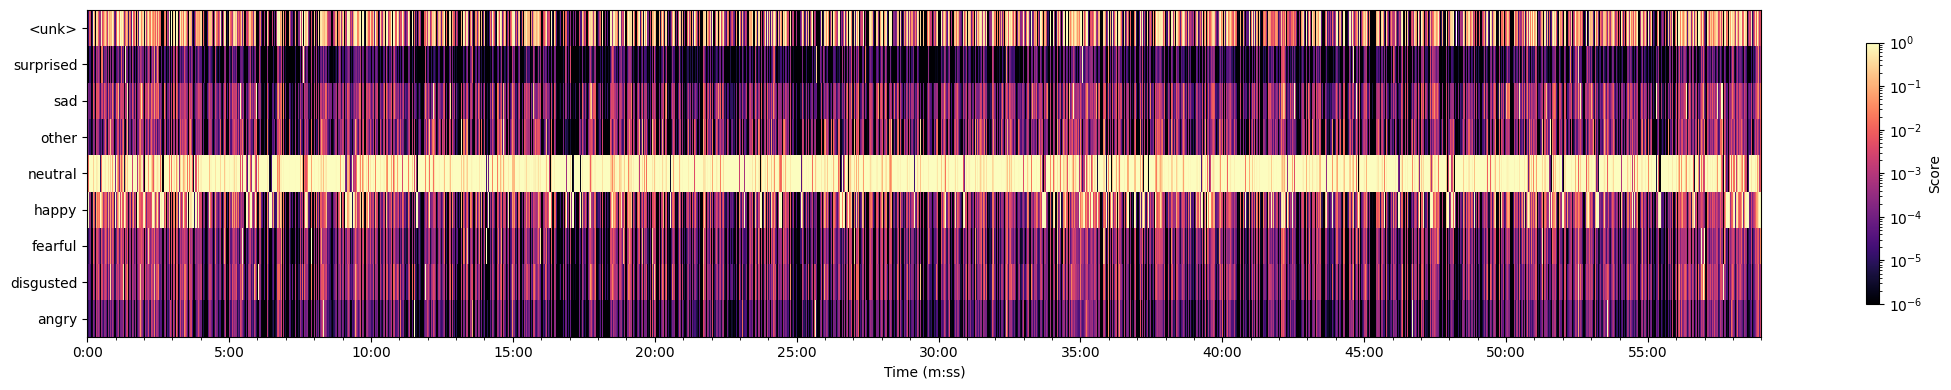

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

hop_sec = 1.0
n_windows = scores.shape[0]

time_edges = np.arange(n_windows + 1) * hop_sec
label_edges = np.arange(len(labels) + 1)

fig, ax = plt.subplots(figsize=(22, 4))
mesh = ax.pcolormesh(
    time_edges, label_edges, scores.T,
    cmap="magma",
    norm=LogNorm(vmin=1e-6, vmax=1),
)

ax.set_yticks(np.arange(len(labels)) + 0.5)
ax.set_yticklabels(labels)

def fmt_time(x, _):
    m, s = divmod(int(x), 60)
    return f"{m}:{s:02d}"

ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
ax.xaxis.set_major_locator(ticker.MultipleLocator(300))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(60))
ax.set_xlabel("Time (m:ss)")

fig.colorbar(mesh, ax=ax, label="Score", shrink=0.8)
plt.tight_layout()
plt.show()

In [17]:
res = model.generate(
    input=batch,
    fs=16000,
    granularity="utterance",
    extract_embedding=False,
)

rtf_avg: 0.051: 100%|██████████| 10/10 [00:01<00:00,  9.77it/s]                                                                                      


In [18]:
res

[{'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他/other',
   '难过/sad',
   '吃惊/surprised',
   '<unk>'],
  'scores': [8.726299824957096e-07,
   2.104871327901492e-06,
   4.79837126476923e-06,
   2.3356566089205444e-05,
   0.9999545812606812,
   3.6768184941138315e-08,
   7.252507657540264e-06,
   5.2885279728798196e-06,
   1.809293848964444e-06]},
 {'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他/other',
   '难过/sad',
   '吃惊/surprised',
   '<unk>'],
  'scores': [1.1675102541630622e-05,
   2.148649946320802e-05,
   3.109378303634003e-05,
   0.9910483956336975,
   0.00013521565415430814,
   6.072374162613414e-05,
   3.4670425520744175e-05,
   2.3401678390655434e-06,
   0.00865436252206564]},
 {'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他